# Explorasi Data


### Import Library yang Diperlukan
Import semua library yang dibutuhkan. pandas untuk data, psycopg2 untuk DB, numpy dan scipy untuk stats, matplotlib untuk plot. Tambahkan !pip install ... jika library belum ada.

In [3]:
%pip install pandas sqlalchemy psycopg2-binary python-dotenv numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 33.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import psycopg2
from psycopg2 import sql
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

### Load Dataset dari CSV dan Preview Awal
Buka file **data.csv** ke dalam DataFrame menggunakan pandas. Setelah itu, tampilkan **5 baris teratas (preview)** serta **informasi dataset** (tipe data tiap kolom dan jumlah baris). Langkah ini berguna untuk memahami struktur data sebelum dilakukan pembersihan. Jika file tidak ditemukan, akan muncul error—pastikan file berada di folder yang sama.


In [1]:
from google.colab import files
uploaded = files.upload()


Saving ObesityDataSet.csv to ObesityDataSet.csv


In [5]:
# Load CSV ke DataFrame
df = pd.read_csv("ObesityDataSet.csv")


# Preview data
print("Preview Data:")
print(df.head())

# Info data awal (tipe data, non-null count)
print("\nInfo Data Awal:")
print(df.info())

Preview Data:
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transpor

### Setup Database PostgreSQL (Konfigurasi,Koneksi,Create Table,Insert Data)
Sebelum kita bisa mengolah data di PostgreSQL, ada beberapa langkah penting yang perlu dilakukan. Pertama adalah konfigurasi. Pada tahap ini kita menyiapkan PostgreSQL di komputer, mulai dari proses instalasi hingga pengaturan username, password, dan port. Konfigurasi ini penting agar sistem database bisa dijalankan dan siap digunakan.

Setelah itu, kita masuk ke tahap koneksi. Koneksi berarti menghubungkan PostgreSQL dengan aplikasi lain, misalnya Python atau Power BI. Untuk membuat koneksi, kita perlu memasukkan informasi dasar seperti host, port, username, password, dan nama database. Dengan adanya koneksi ini, aplikasi bisa membaca dan menulis data di PostgreSQL.

Langkah berikutnya adalah create table. Tabel di PostgreSQL berfungsi seperti lembar kerja di Excel, tempat kita menyimpan data. Saat membuat tabel, kita harus menentukan nama tabel, kolom apa saja yang dibutuhkan, serta tipe data setiap kolom. Misalnya, kolom id untuk nomor unik, name untuk nama, dan age untuk usia.

Tahap terakhir adalah insert data. Di sinilah kita mulai mengisi tabel dengan data yang sudah ada. Data bisa dimasukkan dengan mengetik langsung perintah SQL INSERT INTO, atau bisa juga diimpor dari file eksternal seperti CSV maupun Excel.

Dengan menyelesaikan empat tahap ini—konfigurasi, koneksi, membuat tabel, dan memasukkan data—database PostgreSQL sudah siap dipakai untuk eksplorasi maupun analisis data lebih lanjut.

In [ ]:
import psycopg2
import pandas as pd
from sqlalchemy import create_engine

# --- KONFIGURASI DATABASE ---
PG_HOST = "localhost"
PG_PORT = "5432"
PG_DB = "PSD"
PG_USER = "postgres"
PG_PASSWORD = "abdi19"

# --- 1. KONEKSI KE DATABASE ---
try:
    conn = psycopg2.connect(
        host=PG_HOST,
        port=PG_PORT,
        dbname=PG_DB,
        user=PG_USER,
        password=PG_PASSWORD
    )
    cur = conn.cursor()
    print("✅ Koneksi berhasil ke PostgreSQL")
except Exception as e:
    print("❌ Gagal koneksi:", e)


# --- 2. BUAT TABEL ---
create_table_query = """
CREATE TABLE IF NOT EXISTS obesity_data (
    "Gender" TEXT,
    "Age" NUMERIC,
    "Height" NUMERIC,
    "Weight" NUMERIC,
    "family_history_with_overweight" TEXT,
    "FAVC" TEXT,
    "FCVC" NUMERIC,
    "NCP" NUMERIC,
    "CAEC" TEXT,
    "SMOKE" TEXT,
    "CH2O" NUMERIC,
    "SCC" TEXT,
    "FAF" NUMERIC,
    "TUE" NUMERIC,
    "CALC" TEXT,
    "MTRANS" TEXT,
    "NObeyesdad" TEXT
);
"""
cur.execute(create_table_query)
conn.commit()
print("✅ Tabel 'obesity_data' siap.")


# --- 3. BACA DATA DARI CSV ---
csv_file = "ObesityDataSet.csv"  # ganti dengan nama file csv kamu
df = pd.read_csv(csv_file)
print("✅ Data CSV berhasil dibaca, jumlah baris:", len(df))


# --- 4. INPUT DATA KE POSTGRES ---
engine = create_engine(
    f"postgresql://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}"
)

# Masukkan data, ganti 'replace' -> kalau tabel sudah ada akan ditimpa
# Kalau mau nambahin data gunakan 'append'
df.to_sql("obesity_data", engine, if_exists="append", index=False)
print("✅ Data berhasil dimasukkan ke PostgreSQL.")


# --- 5. CEK DATA SAMPLE ---
cur.execute("SELECT * FROM obesity_data LIMIT 5;")
rows = cur.fetchall()
print("\nSample data dari database:")
for row in rows:
    print(row)




✅ Koneksi berhasil ke PostgreSQL
✅ Tabel 'obesity_data' siap.
✅ Data CSV berhasil dibaca, jumlah baris: 2111
✅ Data berhasil dimasukkan ke PostgreSQL.

Sample data dari database:
('Female', Decimal('21.0'), Decimal('1.62'), Decimal('64.0'), 'yes', 'no', Decimal('2.0'), Decimal('3.0'), 'Sometimes', 'no', Decimal('2.0'), 'no', Decimal('0.0'), Decimal('1.0'), 'no', 'Public_Transportation', 'Normal_Weight')
('Female', Decimal('21.0'), Decimal('1.52'), Decimal('56.0'), 'yes', 'no', Decimal('3.0'), Decimal('3.0'), 'Sometimes', 'yes', Decimal('3.0'), 'yes', Decimal('3.0'), Decimal('0.0'), 'Sometimes', 'Public_Transportation', 'Normal_Weight')
('Male', Decimal('23.0'), Decimal('1.8'), Decimal('77.0'), 'yes', 'no', Decimal('2.0'), Decimal('3.0'), 'Sometimes', 'no', Decimal('2.0'), 'no', Decimal('2.0'), Decimal('1.0'), 'Frequently', 'Public_Transportation', 'Normal_Weight')
('Male', Decimal('27.0'), Decimal('1.8'), Decimal('87.0'), 'no', 'no', Decimal('3.0'), Decimal('3.0'), 'Sometimes', 'no', D

### EDA - Tipe Data dan Missing Values
Exploratory Data Analysis (EDA) pada bagian tipe data dan missing values bertujuan untuk memahami struktur awal dataset sebelum dilakukan analisis lebih lanjut. Tipe data penting untuk diketahui karena setiap kolom memiliki karakteristik yang berbeda, misalnya angka (numerik), teks (string), atau tanggal (datetime), sehingga memengaruhi cara pengolahan datanya. Sementara itu, pengecekan missing values dilakukan untuk melihat apakah ada data yang kosong atau tidak terisi. Data yang hilang ini perlu ditangani, karena jika dibiarkan bisa menimbulkan bias atau error dalam proses analisis dan pemodelan. Dengan memahami tipe data serta keberadaan missing values sejak awal, kita bisa menentukan langkah pembersihan (data cleaning) yang tepat agar analisis berikutnya lebih akurat.

In [ ]:
# --- 1. TIPE DATA ---
print("📌 Tipe Data Tiap Kolom:")
print(df.dtypes)


📌 Tipe Data Tiap Kolom:
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object


In [ ]:
# --- 2. MISSING VALUES ---
print("📌 Missing Values per Kolom:")
print(df.isnull().sum())


📌 Missing Values per Kolom:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


### EDA - Outlier Analisis dengan IQR
Pada tahap EDA - Outlier Analisis dengan IQR, kita mencoba mendeteksi data yang nilainya menyimpang jauh dari mayoritas data lainnya dengan menggunakan metode Interquartile Range (IQR). IQR dihitung dari selisih antara kuartil atas (Q3) dan kuartil bawah (Q1), lalu digunakan untuk menentukan batas bawah dan batas atas. Data yang berada di luar rentang tersebut dianggap sebagai outlier. Analisis ini penting karena outlier bisa memengaruhi hasil analisis dan membuat kesimpulan menjadi tidak akurat, sehingga perlu dipahami apakah outlier tersebut wajar (misalnya kasus khusus) atau justru perlu dibersihkan.

In [ ]:
# --- 3. OUTLIER ANALISIS (IQR METHOD) ---
import numpy as np
import pandas as pd

numeric_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

outlier_summary = []

for col in numeric_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary.append({
            "Kolom": col,
            "Jumlah Outlier": len(outliers),
            "Batas Bawah": round(lower_bound,2),
            "Batas Atas": round(upper_bound,2)
        })

outlier_df = pd.DataFrame(outlier_summary)
print("📌 Outlier Analisis (IQR):")
print(outlier_df)


📌 Outlier Analisis (IQR):
    Kolom  Jumlah Outlier  Batas Bawah  Batas Atas
0     Age             168        10.87       35.08
1  Height               1         1.42        1.98
2  Weight               1         2.54      170.37
3    FCVC               0         0.50        4.50
4     NCP             579         2.15        3.51
5    CH2O               0         0.25        3.82
6     FAF               0        -2.19        3.98
7     TUE               0        -1.50        2.50


### EDA - Konsistensi Data dan Duplikat
Pada tahap EDA - Konsistensi Data dan Duplikat, fokusnya adalah memastikan bahwa data yang digunakan tidak memiliki kejanggalan seperti format yang tidak seragam (misalnya penulisan “Yes” dan “YES” pada kolom kategori) serta tidak ada baris data yang tercatat lebih dari sekali. Data duplikat bisa menimbulkan bias karena informasi yang sama dihitung berkali-kali, sedangkan inkonsistensi bisa membuat analisis sulit dilakukan. Oleh karena itu, langkah ini penting untuk membersihkan data agar hasil analisis lebih akurat dan dapat dipercaya.

In [ ]:
# --- 4. KONSISTENSI DATA ---
print("📌 Konsistensi Data:")

# cek duplikat
print("- Jumlah duplikat baris:", df.duplicated().sum())

# cek nilai unik untuk kolom kategorikal
categorical_cols = [
    "Gender", "family_history_with_overweight", "FAVC", "CAEC",
    "SMOKE", "SCC", "CALC", "MTRANS", "NObeyesdad"
]

for col in categorical_cols:
    if col in df.columns:
        print(f"\nKolom '{col}' punya {df[col].nunique()} nilai unik:")
        print(df[col].unique())


📌 Konsistensi Data:
- Jumlah duplikat baris: 24

Kolom 'Gender' punya 2 nilai unik:
['Female' 'Male']

Kolom 'family_history_with_overweight' punya 2 nilai unik:
['yes' 'no']

Kolom 'FAVC' punya 2 nilai unik:
['no' 'yes']

Kolom 'CAEC' punya 4 nilai unik:
['Sometimes' 'Frequently' 'Always' 'no']

Kolom 'SMOKE' punya 2 nilai unik:
['no' 'yes']

Kolom 'SCC' punya 2 nilai unik:
['no' 'yes']

Kolom 'CALC' punya 4 nilai unik:
['no' 'Sometimes' 'Frequently' 'Always']

Kolom 'MTRANS' punya 5 nilai unik:
['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']

Kolom 'NObeyesdad' punya 7 nilai unik:
['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


### EDA - Statistik Deskriptif dan Visualisasi
Statistik deskriptif digunakan untuk memahami gambaran umum dari data, seperti nilai rata-rata, minimum, maksimum, hingga sebaran (distribusi) pada setiap kolom numerik. Dengan cara ini, kita bisa melihat tren dasar, pola, dan potensi anomali dalam data. Selain itu, visualisasi seperti histogram atau boxplot membantu memperjelas distribusi nilai, apakah data menyebar merata, condong ke satu sisi, atau memiliki outlier. Jadi, statistik deskriptif dan visualisasi ini berfungsi sebagai langkah awal untuk mengenali karakteristik dataset sebelum dilakukan analisis lebih lanjut.


📌 Statistik Deskriptif Numerik:
               Age       Height       Weight         FCVC          NCP  \
count  2111.000000  2111.000000  2111.000000  2111.000000  2111.000000   
mean     24.312600     1.701677    86.586058     2.419043     2.685628   
std       6.345968     0.093305    26.191172     0.533927     0.778039   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      19.947192     1.630000    65.473343     2.000000     2.658738   
50%      22.777890     1.700499    83.000000     2.385502     3.000000   
75%      26.000000     1.768464   107.430682     3.000000     3.000000   
max      61.000000     1.980000   173.000000     3.000000     4.000000   

              CH2O          FAF          TUE  
count  2111.000000  2111.000000  2111.000000  
mean      2.008011     1.010298     0.657866  
std       0.612953     0.850592     0.608927  
min       1.000000     0.000000     0.000000  
25%       1.584812     0.124505     0.000000  
50%       2.000000

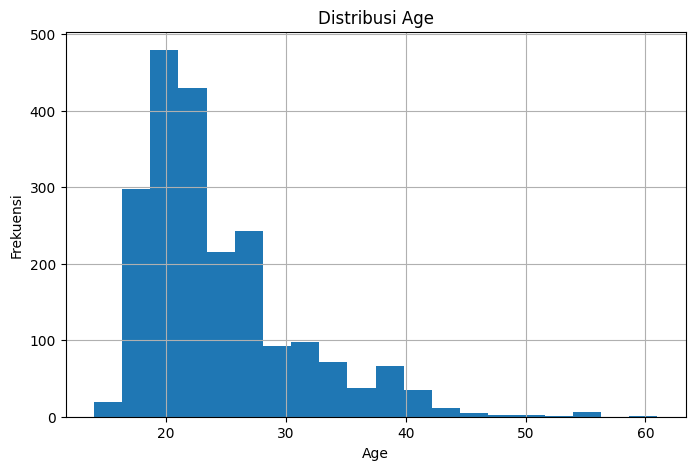

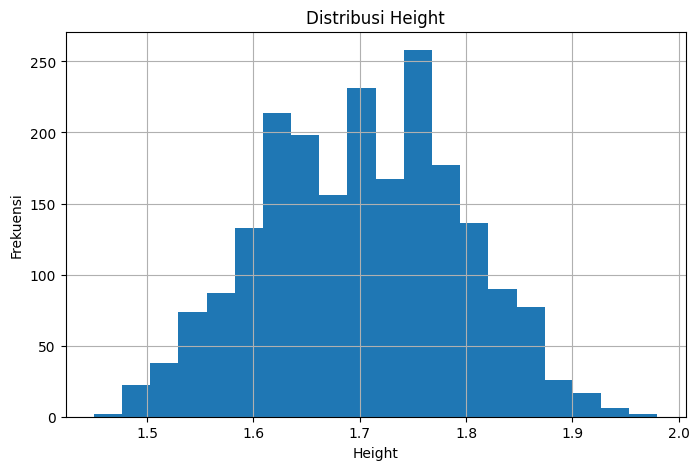

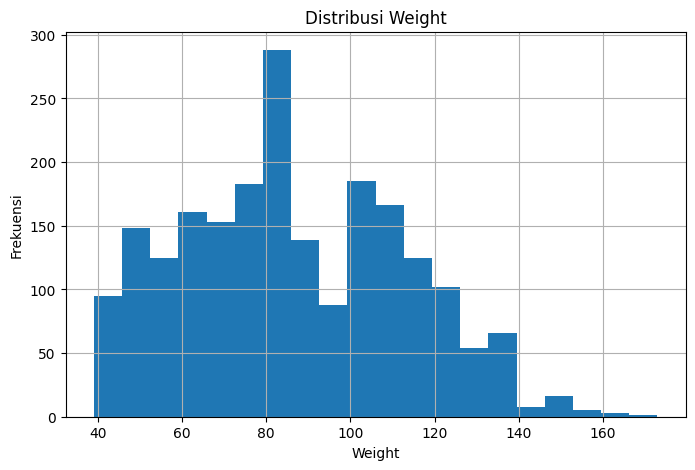

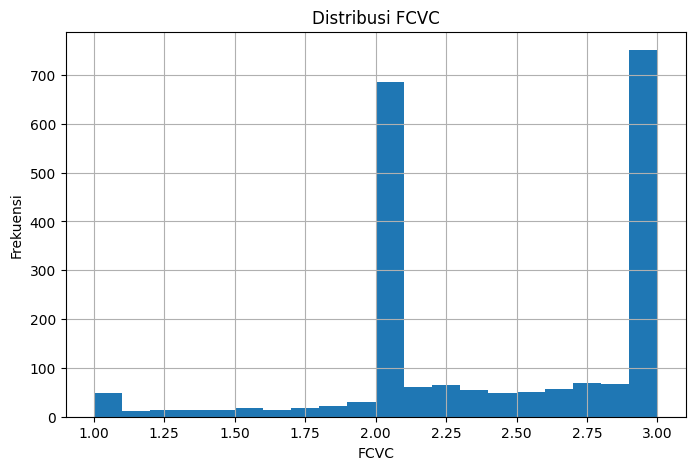

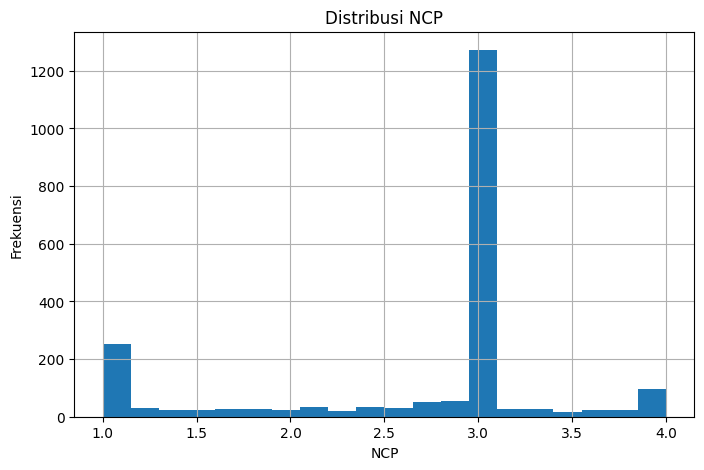

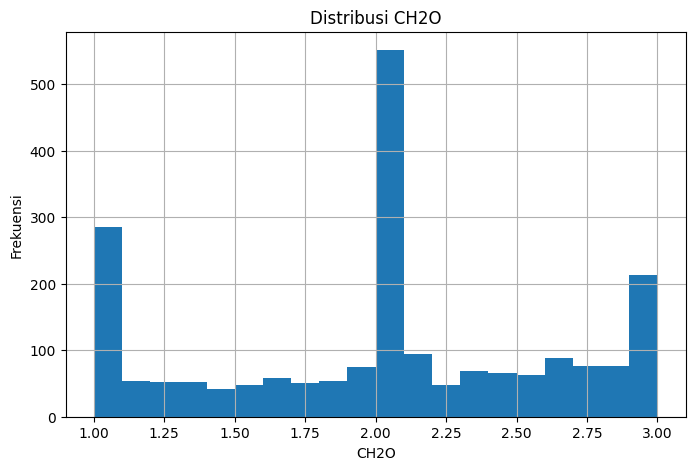

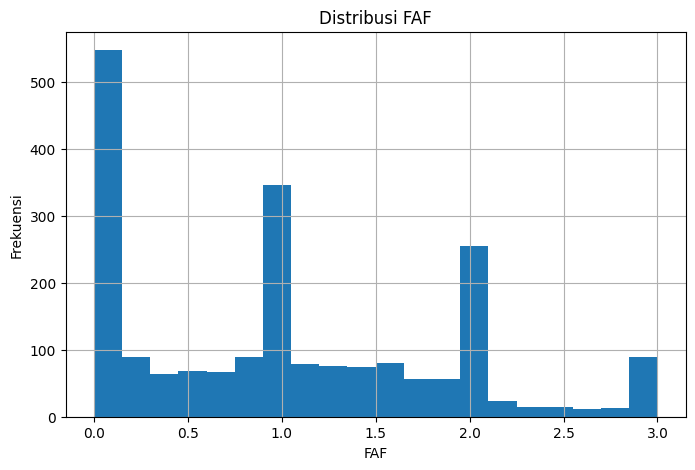

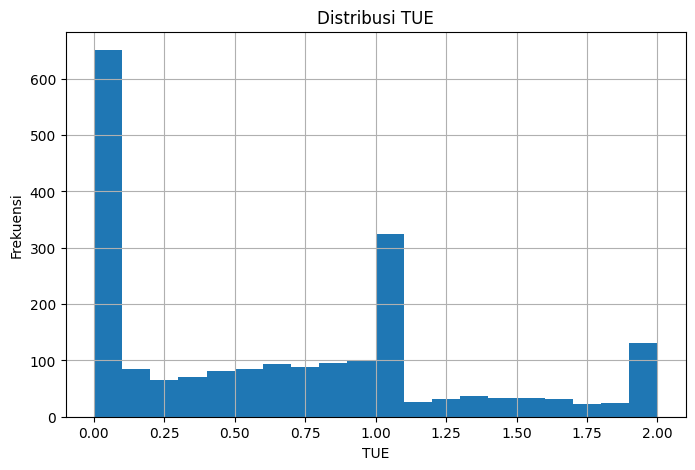

In [ ]:
import matplotlib.pyplot as plt

# --- Statistik Deskriptif ---
print("\n📌 Statistik Deskriptif Numerik:")
print(df[["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]].describe())

# --- Visualisasi Distribusi Histogram ---
numeric_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    df[col].hist(bins=20)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.show()


### EDA - Menggunakan Power BI

#### - Type Data
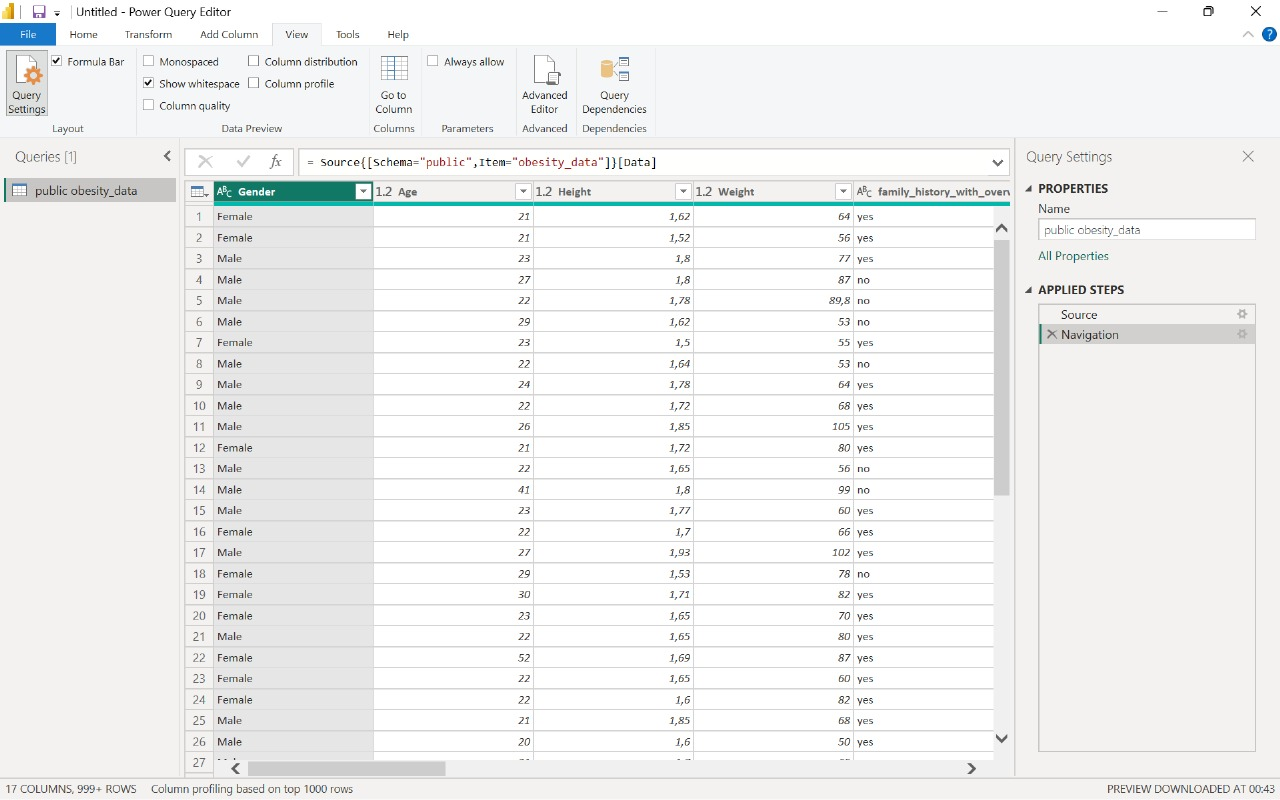


#### - Missing Values

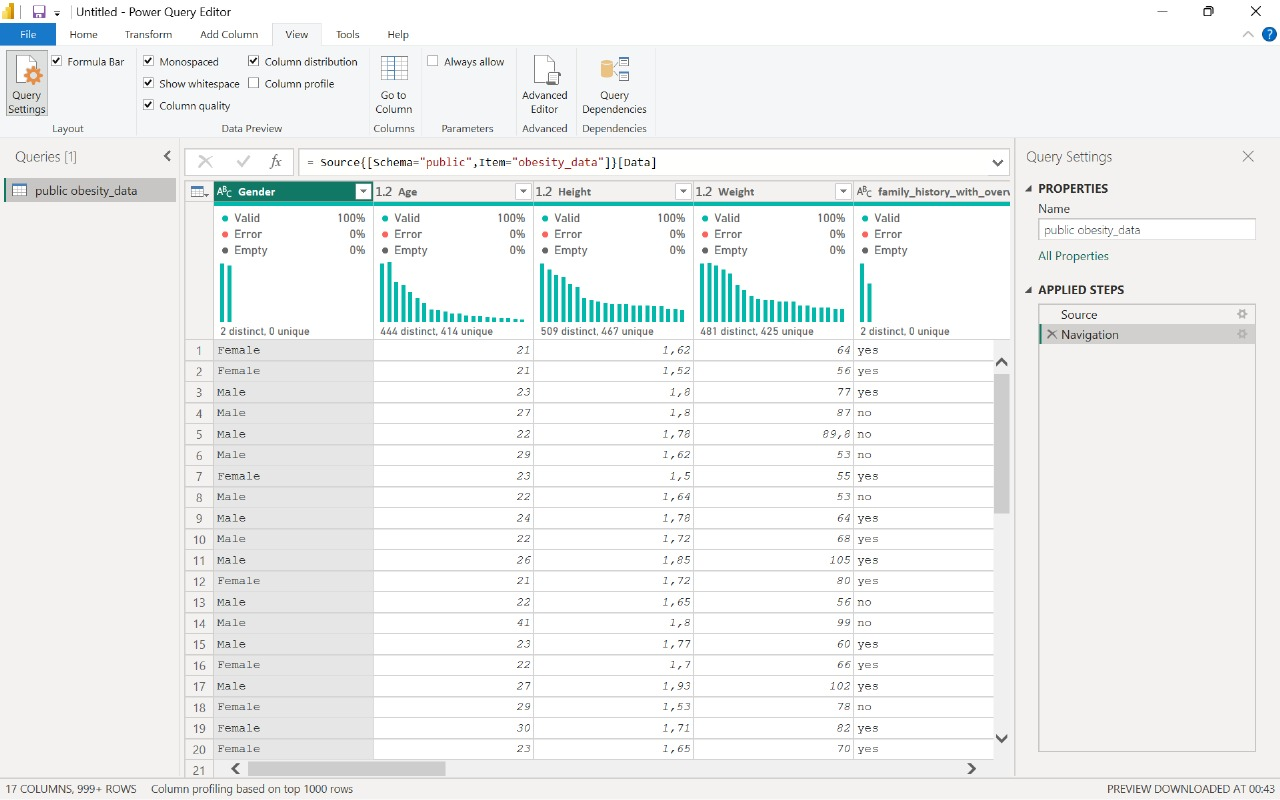

#### - Konsistensi Data
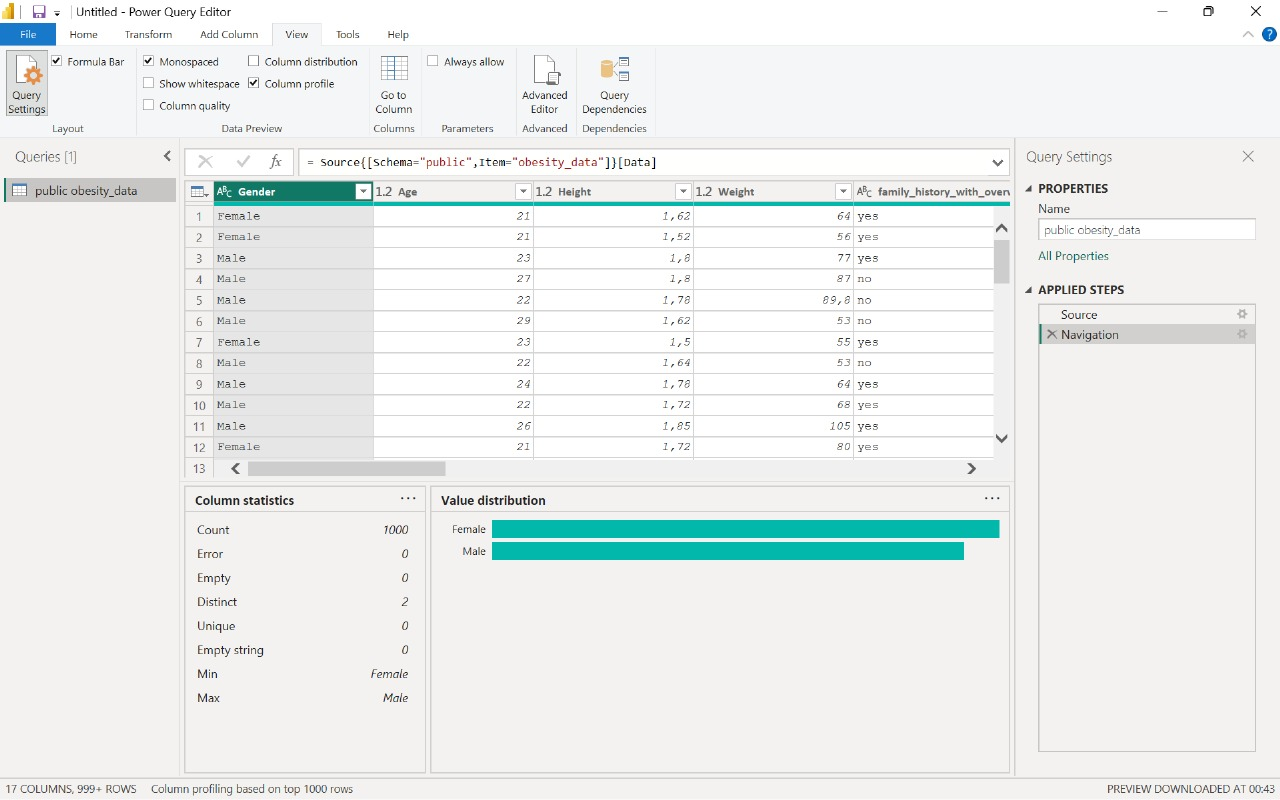


#### - Outlier Analisis
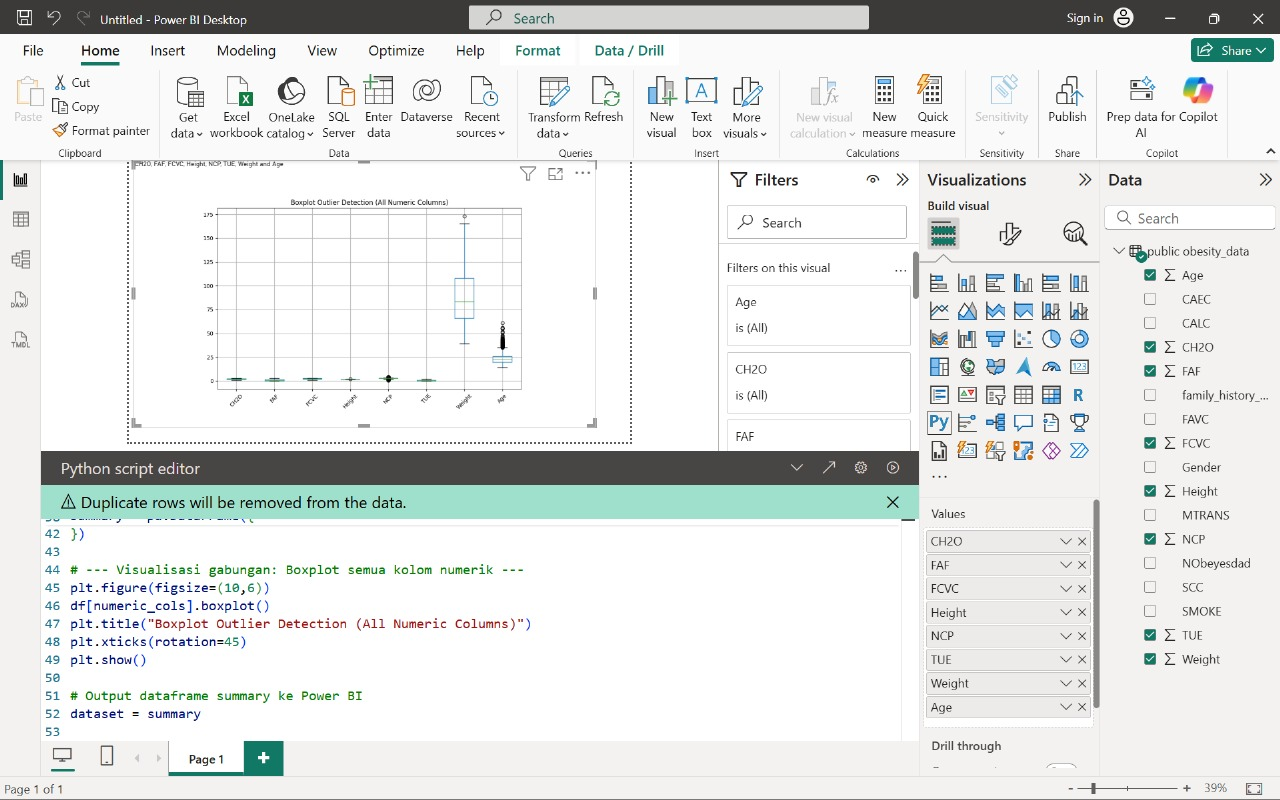
